In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from dataloader import DataLoader
from datasets import  DummyDataset, FashionMNISTDataset
from datasets.utils.random_split import random_split

from datasets.utils.trasnforms import (
    Compose,
    ToFloat,
    Normalize,
    Scale,
)

from network import Network
from layers import ReLU, Linear, Flatten, Dropout

from losses import SoftmaxCrossEntropy
from optimizers.scheduler import StepLR
from optimizers import Adam

from train import Trainer
from eval import Evaluator

%load_ext autoreload
%autoreload 2

# Dummy dataset overfitting example

In [8]:
batch_size = 4

train_dataset = DummyDataset(
    num_samples=20,
    num_features=10,
    num_classes=3,
    seed=42,
)

val_dataset = train_dataset

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    drop_last=False,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    drop_last=False,
    shuffle=False
)

model = Network([
    Linear(10, 150),
    ReLU(),
    Linear(150, 3)
])

loss_func = SoftmaxCrossEntropy()
optimizer = Adam(
    parameters=model.parameters(), 
    learning_rate=1e-3,
    weight_decay=1e-4
)

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_func=loss_func,
    optimizer=optimizer
)

history = trainer.train(epochs=20)

(Epoch 1 / 20) train loss: 1.188488; train accuracy: 0.5500; val loss: 1.084750; val accuracy: 0.5500
(Epoch 2 / 20) train loss: 1.047271; train accuracy: 0.5500; val loss: 0.963306; val accuracy: 0.6000
(Epoch 3 / 20) train loss: 0.938831; train accuracy: 0.6500; val loss: 0.866850; val accuracy: 0.7000
(Epoch 4 / 20) train loss: 0.852190; train accuracy: 0.7000; val loss: 0.788885; val accuracy: 0.7000
(Epoch 5 / 20) train loss: 0.764567; train accuracy: 0.7000; val loss: 0.726399; val accuracy: 0.8000
(Epoch 6 / 20) train loss: 0.713132; train accuracy: 0.8000; val loss: 0.668238; val accuracy: 0.8000
(Epoch 7 / 20) train loss: 0.653487; train accuracy: 0.8000; val loss: 0.618691; val accuracy: 0.8000
(Epoch 8 / 20) train loss: 0.603982; train accuracy: 0.8000; val loss: 0.575307; val accuracy: 0.8000
(Epoch 9 / 20) train loss: 0.564336; train accuracy: 0.8000; val loss: 0.533208; val accuracy: 0.8000
(Epoch 10 / 20) train loss: 0.523415; train accuracy: 0.8000; val loss: 0.496494; 

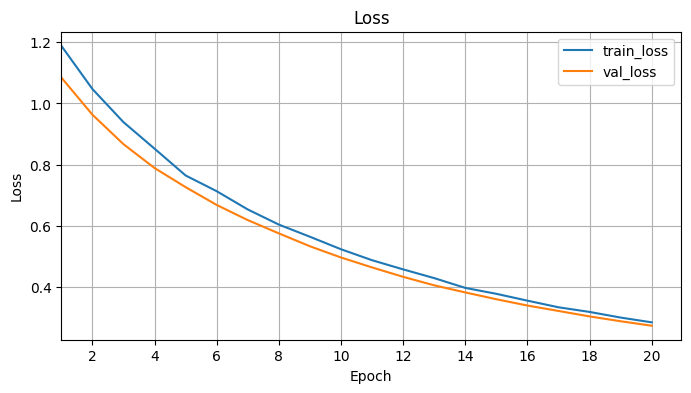

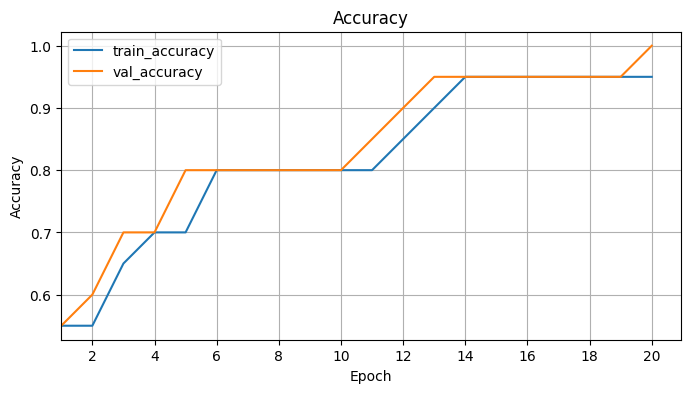

In [9]:
history.plot_loss()
history.plot_accuracy()

## Fashion MNIST dataset

In [10]:
data_path = "data/fashion-mnist/train-images-idx3-ubyte"
labels_path = "data/fashion-mnist/train-labels-idx1-ubyte"

transform = Compose([
    ToFloat(),
    Scale(255.0),
    Normalize(mean=0.2860, std=0.3530),
])

dataset = FashionMNISTDataset(
    data_path=data_path,
    labels_path=labels_path,
    transform=transform,
)

splits = random_split(
    dataset,
    {"train": 0.8, "val": 0.2},
    seed=42,
)

train_dataset = splits["train"]
val_dataset = splits["val"]

In [11]:
batch_size = 128

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
)

In [15]:
model = Network([
    Flatten(),
    Linear(784, 1024),
    ReLU(),
    Dropout(0.1),

    Linear(1024, 512),
    ReLU(),
    Dropout(0.1),

    Linear(512, 10),
], model_name="fashion-mnist-nn")

In [13]:
lr = 1e-3
wd = 5e-5

loss_func = SoftmaxCrossEntropy()
optimizer = Adam(
    parameters=model.parameters(),
    learning_rate=1e-3,
    weight_decay=wd
)
scheduler = StepLR(
    optimizer,
    step_size=10,
    gamma=0.5
)

In [ ]:
epochs = 30

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_func=loss_func,
    optimizer=optimizer,
    scheduler=scheduler,
)

history = trainer.train(epochs=epochs, checkpoint_monitor="accuracy", checkpoint_mode="max")

Model accuracy: 0.07916666666666666


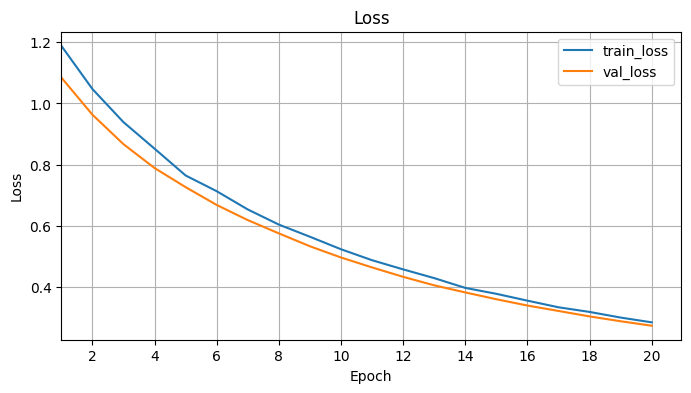

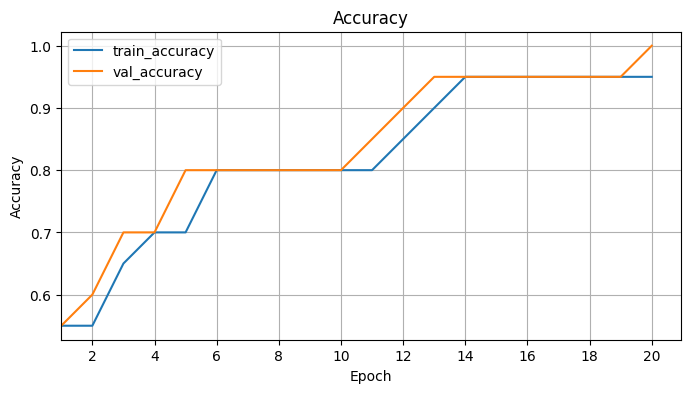

In [27]:
evaluator = Evaluator(
    model=model,
    class_names=FashionMNISTDataset.CLASS_NAMES
)

results = evaluator.evaluate(val_loader)
print(f"Model accuracy: {results["accuracy"]}")

history.plot_loss()
history.plot_accuracy()

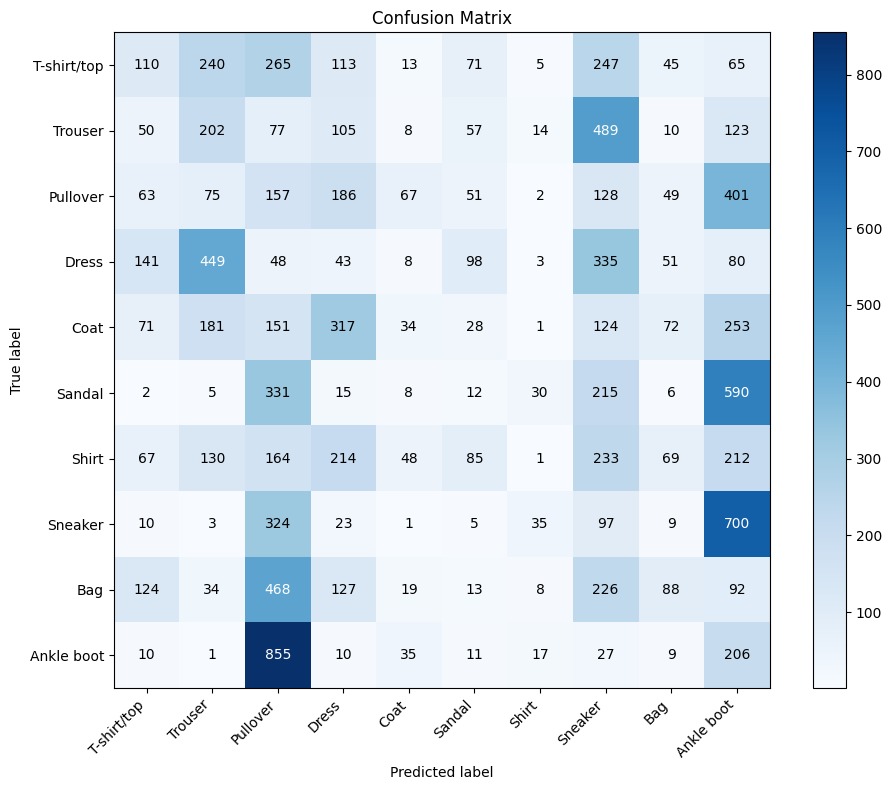

In [29]:
evaluator.plot_confusion_matrix(results)

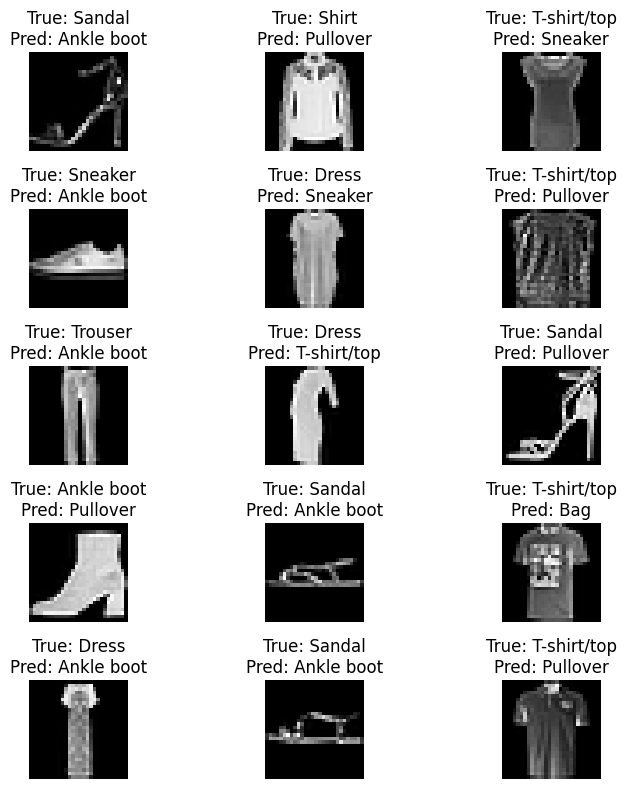

In [33]:
evaluator.plot_wrong_predictions(
    results,
    max_images=15,
    image_shape=(28, 28)
)

In [48]:
model.save_model()

## Test

In [34]:
test_data_path = "data/fashion-mnist/train-images-idx3-ubyte"
test_labels_path = "data/fashion-mnist/train-labels-idx1-ubyte"

test_dataset = FashionMNISTDataset(
    data_path=test_data_path,
    labels_path=test_labels_path,
    transform=transform,
)

test_index = np.random.randint(len(test_dataset))

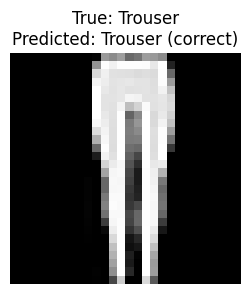

In [30]:
sample = test_dataset[test_index]
x = sample["data"]
y_true = sample["label"]

scores = model.forward(x[None, :])
y_pred = np.argmax(scores, axis=1)[0]

y_true_name = test_dataset.CLASS_NAMES[y_true]
y_pred_name = test_dataset.CLASS_NAMES[y_pred]

is_correct = y_pred == y_true
status = "correct" if is_correct else "wrong"

plt.figure(figsize=(3, 3))
plt.imshow(x.reshape(28, 28), cmap="gray")
plt.title(f"True: {y_true_name}\nPredicted: {y_pred_name} ({status})")
plt.axis("off")
plt.show()